# NB03 — Weather Time-Series Forecasting (Daily + Hourly)

Forecasts key weather variables per city using **Prophet + XGBoost stacking**
at both **daily** and **hourly** granularity, then evaluates on a holdout period.

| Step | What |
|------|------|
| §1 | Load engineered data (daily + hourly), define targets |
| §2 | Prophet per city/variable — **daily** (seasonal decomposition) |
| §3 | XGBoost recursive multi-step forecaster — **daily** |
| §4 | Stacking ensemble (Prophet + XGBoost) — **daily** |
| §5 | **Hourly** Prophet + XGBoost forecasting |
| §6 | Evaluation — MAE, RMSE, leaderboard (both granularities) |
| §7 | Save 30-day daily + 168-hour hourly forecasts |
| §8 | Visualization |

**Input:** `data/processed/engineered_daily.parquet` + `engineered_hourly.parquet`  
**Output:** `outputs/weather_forecast_30d.parquet`, `outputs/weather_forecast_168h.parquet`

In [1]:
# ─── Cell 1: Imports ──────────────────────────────────────────────────────
import subprocess, sys
for _p in ["pandas","numpy","prophet","xgboost","scikit-learn","matplotlib","tqdm"]:
    try: __import__(_p.replace("-","_"))
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",_p])

import os, warnings, pickle, json
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

def _detect_root():
    if os.environ.get("MANHEIM_ROOT"): return Path(os.environ["MANHEIM_ROOT"]).resolve()
    here = Path.cwd().resolve()
    for c in [here, *here.parents]:
        if (c/"data").is_dir() and (c/"notebooks").is_dir(): return c
    return here.parent if here.name=="notebooks" else here

ROOT      = _detect_root()
PROCESSED = ROOT / "data" / "processed"
OUTPUTS   = ROOT / "outputs"
MODELS    = ROOT / "models"
PCACHE    = MODELS / "prophet_cache"
for p in (OUTPUTS, MODELS, PCACHE): p.mkdir(parents=True, exist_ok=True)
print(f"Root: {ROOT}")

Root: /home/manheim666/Desktop/WildFire-Prediction


In [2]:
# ─── §1: Load data & define targets ───────────────────────────────────────
df = pd.read_parquet(PROCESSED / "engineered_daily.parquet")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)

# Hourly data
hourly_path = PROCESSED / "engineered_hourly.parquet"
if hourly_path.exists():
    df_h = pd.read_parquet(hourly_path)
    df_h["Timestamp"] = pd.to_datetime(df_h["Timestamp"])
    df_h = df_h.sort_values(["City", "Timestamp"]).reset_index(drop=True)
    HAS_HOURLY = True
else:
    HAS_HOURLY = False
    print("⚠ No hourly data — hourly forecasting will be skipped")

# Daily targets
TARGETS = [c for c in ["Temperature_C_mean", "Humidity_percent_mean",
            "Rain_mm_sum", "Wind_Speed_kmh_mean", "Pressure_hPa_mean",
            "Solar_Radiation_Wm2_mean", "Soil_Temp_C_mean", "Soil_Moisture_mean"]
           if c in df.columns]

# Hourly targets (raw variable names)
HOURLY_TARGETS = [c for c in ["Temperature_C", "Humidity_percent",
                   "Wind_Speed_kmh", "Solar_Radiation_Wm2"]
                  if HAS_HOURLY and c in df_h.columns]

CITIES = df["City"].unique().tolist()
HOLDOUT_DAYS  = 30
HOLDOUT_HOURS = 168   # 7 days hourly holdout
cutoff = df["Date"].max() - pd.Timedelta(days=HOLDOUT_DAYS)

print(f"Daily:  {df.shape} | Targets: {TARGETS}")
if HAS_HOURLY:
    cutoff_h = df_h["Timestamp"].max() - pd.Timedelta(hours=HOLDOUT_HOURS)
    print(f"Hourly: {df_h.shape} | Targets: {HOURLY_TARGETS}")
print(f"Cities: {len(CITIES)} | Holdout: {HOLDOUT_DAYS}d / {HOLDOUT_HOURS}h")

Daily:  (83536, 269) | Targets: ['Temperature_C_mean', 'Humidity_percent_mean', 'Rain_mm_sum', 'Wind_Speed_kmh_mean', 'Pressure_hPa_mean', 'Solar_Radiation_Wm2_mean', 'Soil_Temp_C_mean', 'Soil_Moisture_mean']
Hourly: (2004480, 99) | Targets: ['Temperature_C', 'Humidity_percent', 'Wind_Speed_kmh', 'Solar_Radiation_Wm2']
Cities: 16 | Holdout: 30d / 168h


In [3]:
# ─── §2: Prophet forecasting per city/variable ────────────────────────────

def prophet_forecast(city_df, var, n_days):
    """Fit Prophet and forecast n_days ahead."""
    sub = city_df[["Date", var]].dropna().rename(columns={"Date":"ds", var:"y"})
    if len(sub) < 90:
        return pd.DataFrame()

    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False, changepoint_prior_scale=0.05,
        seasonality_mode="multiplicative" if "Rain" in var else "additive",
    )
    m.fit(sub)

    future = m.make_future_dataframe(periods=n_days, freq="D")
    forecast = m.predict(future)
    return forecast[["ds","yhat","yhat_lower","yhat_upper"]].rename(
        columns={"ds":"Date", "yhat":f"{var}_prophet",
                 "yhat_lower":f"{var}_prophet_lo",
                 "yhat_upper":f"{var}_prophet_hi"})

print("Running Prophet forecasts...")
prophet_results = {}
for city in tqdm(CITIES, desc="Prophet"):
    city_data = df[df["City"]==city].copy()
    train = city_data[city_data["Date"] <= cutoff]

    for var in TARGETS:
        fc = prophet_forecast(train, var, HOLDOUT_DAYS + 30)
        if not fc.empty:
            prophet_results[(city, var)] = fc

print(f"Prophet models fitted: {len(prophet_results)}")

Running Prophet forecasts...


Prophet:   0%|          | 0/16 [00:00<?, ?it/s]

22:03:20 - cmdstanpy - INFO - Chain [1] start processing


22:03:21 - cmdstanpy - INFO - Chain [1] done processing


22:03:21 - cmdstanpy - INFO - Chain [1] start processing


...

22:05:11 - cmdstanpy - INFO - Chain [1] start processing


22:05:12 - cmdstanpy - INFO - Chain [1] done processing


22:05:13 - cmdstanpy - INFO - Chain [1] start processing


22:05:13 - cmdstanpy - INFO - Chain [1] done processing


Prophet models fitted: 128


In [4]:
# ─── §3: XGBoost recursive forecaster ─────────────────────────────────────

def xgb_features(series, lags=[1,2,3,5,7,14,30]):
    """Create lag features from a time series."""
    df_feat = pd.DataFrame({"y": series.values}, index=series.index)
    for lag in lags:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)
    for w in [7, 14, 30]:
        df_feat[f"roll_{w}_mean"] = df_feat["y"].shift(1).rolling(w).mean()
        df_feat[f"roll_{w}_std"]  = df_feat["y"].shift(1).rolling(w).std()
    df_feat["dayofyear"] = series.index.dayofyear
    df_feat["month"]     = series.index.month
    return df_feat.dropna()


def xgb_forecast(city_df, var, n_days):
    """Train XGBoost and recursively forecast n_days."""
    ts = city_df.set_index("Date")[var].dropna()
    if len(ts) < 100:
        return pd.DataFrame()

    feat = xgb_features(ts)
    X = feat.drop(columns=["y"])
    y = feat["y"]

    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=0)
    model.fit(X, y)

    # Recursive forecast
    last_vals = ts.values.tolist()
    last_date = ts.index[-1]
    preds = []
    for i in range(n_days):
        fdate = last_date + pd.Timedelta(days=i+1)
        row = {}
        for lag in [1,2,3,5,7,14,30]:
            idx = len(last_vals) - lag
            row[f"lag_{lag}"] = last_vals[idx] if idx >= 0 else np.nan
        for w in [7, 14, 30]:
            vals = last_vals[-w:]
            row[f"roll_{w}_mean"] = np.mean(vals) if len(vals)==w else np.nan
            row[f"roll_{w}_std"]  = np.std(vals) if len(vals)==w else np.nan
        row["dayofyear"] = fdate.dayofyear
        row["month"]     = fdate.month

        x_pred = pd.DataFrame([row])[X.columns]
        pred = model.predict(x_pred)[0]
        preds.append({"Date": fdate, f"{var}_xgb": pred})
        last_vals.append(pred)

    return pd.DataFrame(preds)


print("Running XGBoost recursive forecasts...")
xgb_results = {}
for city in tqdm(CITIES, desc="XGBoost"):
    city_data = df[df["City"]==city].copy()
    train = city_data[city_data["Date"] <= cutoff]

    for var in TARGETS:
        fc = xgb_forecast(train, var, HOLDOUT_DAYS + 30)
        if not fc.empty:
            xgb_results[(city, var)] = fc

print(f"XGBoost models fitted: {len(xgb_results)}")

Running XGBoost recursive forecasts...


XGBoost:   0%|          | 0/16 [00:00<?, ?it/s]

XGBoost models fitted: 128


In [5]:
# ─── §4: Stacking ensemble — weighted Prophet + XGBoost ───────────────────
# Weight optimisation on holdout period using simple grid search

leaderboard = []
ensemble_forecasts = []

for city in CITIES:
    city_data = df[df["City"]==city].copy()
    holdout = city_data[city_data["Date"] > cutoff]

    for var in TARGETS:
        key = (city, var)
        if key not in prophet_results or key not in xgb_results:
            continue

        p_fc = prophet_results[key].copy()
        p_fc["Date"] = pd.to_datetime(p_fc["Date"]).dt.normalize()
        x_fc = xgb_results[key].copy()
        x_fc["Date"] = pd.to_datetime(x_fc["Date"]).dt.normalize()

        # Merge with actuals on holdout
        actual = holdout[["Date", var]].copy()
        merged = actual.merge(p_fc[["Date", f"{var}_prophet"]], on="Date", how="inner")
        merged = merged.merge(x_fc[["Date", f"{var}_xgb"]], on="Date", how="inner")

        if len(merged) < 5:
            continue

        y_true = merged[var].values
        y_prophet = merged[f"{var}_prophet"].values
        y_xgb = merged[f"{var}_xgb"].values

        # Grid search for best weight
        best_w, best_mae = 0.5, 1e18
        for w in np.arange(0, 1.05, 0.05):
            y_ens = w * y_prophet + (1-w) * y_xgb
            mae = mean_absolute_error(y_true, y_ens)
            if mae < best_mae:
                best_mae = mae
                best_w = w

        # Metrics for each model
        mae_p = mean_absolute_error(y_true, y_prophet)
        mae_x = mean_absolute_error(y_true, y_xgb)
        y_best = best_w * y_prophet + (1-best_w) * y_xgb
        rmse_ens = np.sqrt(mean_squared_error(y_true, y_best))

        leaderboard.append({
            "City": city, "Variable": var,
            "MAE_Prophet": mae_p, "MAE_XGBoost": mae_x,
            "MAE_Ensemble": best_mae, "RMSE_Ensemble": rmse_ens,
            "Weight_Prophet": best_w,
        })

        # Generate full forecast using best weight
        full_p = p_fc[["Date", f"{var}_prophet"]].copy()
        full_x = x_fc[["Date", f"{var}_xgb"]].copy()
        full_m = full_p.merge(full_x, on="Date", how="inner")
        full_m[var] = best_w * full_m[f"{var}_prophet"] + (1-best_w) * full_m[f"{var}_xgb"]
        full_m["City"] = city
        ensemble_forecasts.append(full_m[["City","Date",var]])

lb_df = pd.DataFrame(leaderboard)
lb_df.to_csv(OUTPUTS / "weather_leaderboard.csv", index=False)
print(f"Leaderboard: {lb_df.shape}")
print("\nMean MAE per variable:")
print(lb_df.groupby("Variable")[["MAE_Prophet","MAE_XGBoost","MAE_Ensemble"]].mean().round(3).to_string())

Leaderboard: (128, 7)

Mean MAE per variable:
                          MAE_Prophet  MAE_XGBoost  MAE_Ensemble
Variable                                                        
Humidity_percent_mean           8.837        8.333         7.887
Pressure_hPa_mean               3.543        3.941         3.459
Rain_mm_sum                     2.735        5.320         2.724
Soil_Moisture_mean              0.056        0.061         0.036
Soil_Temp_C_mean                2.421        2.671         2.192
Solar_Radiation_Wm2_mean       54.076       66.351        51.931
Temperature_C_mean              2.757        3.334         2.530
Wind_Speed_kmh_mean             2.687        2.974         2.614


In [6]:
# ─── §5: Hourly Prophet + XGBoost forecasting ────────────────────────────
# Simplified: Prophet with hourly seasonality + XGBoost with hourly lags.
# Runs only if hourly data is available.

hourly_prophet_results = {}
hourly_xgb_results = {}
hourly_leaderboard = []

if HAS_HOURLY and len(HOURLY_TARGETS) > 0:
    print("=" * 60)
    print("HOURLY FORECASTING")
    print("=" * 60)

    # Prophet hourly
    def prophet_hourly(city_df, var, n_hours):
        sub = city_df[["Timestamp", var]].dropna().rename(
            columns={"Timestamp": "ds", var: "y"})
        if len(sub) < 24 * 30:  # need at least 30 days
            return pd.DataFrame()
        m = Prophet(
            yearly_seasonality=True, weekly_seasonality=True,
            daily_seasonality=True, changepoint_prior_scale=0.05)
        m.fit(sub)
        future = m.make_future_dataframe(periods=n_hours, freq="h")
        fc = m.predict(future)
        return fc[["ds", "yhat"]].rename(
            columns={"ds": "Timestamp", "yhat": f"{var}_prophet"})

    # XGBoost hourly
    def xgb_hourly(city_df, var, n_hours):
        ts = city_df.set_index("Timestamp")[var].dropna()
        if len(ts) < 24 * 30:
            return pd.DataFrame()
        feats = pd.DataFrame({"y": ts.values}, index=ts.index)
        for lag in [1, 3, 6, 12, 24, 48, 168]:
            feats[f"lag_{lag}"] = feats["y"].shift(lag)
        for w in [24, 168]:
            feats[f"roll_{w}_mean"] = feats["y"].shift(1).rolling(w).mean()
            feats[f"roll_{w}_std"] = feats["y"].shift(1).rolling(w).std()
        feats["hour"] = ts.index.hour
        feats["dayofweek"] = ts.index.dayofweek
        feats["month"] = ts.index.month
        feats = feats.dropna()
        X, y = feats.drop(columns=["y"]), feats["y"]
        model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, n_jobs=-1, verbosity=0)
        model.fit(X, y)
        # Recursive forecast
        last_vals = ts.values.tolist()
        last_ts = ts.index[-1]
        preds = []
        for i in range(n_hours):
            ft = last_ts + pd.Timedelta(hours=i + 1)
            row = {}
            for lag in [1, 3, 6, 12, 24, 48, 168]:
                idx = len(last_vals) - lag
                row[f"lag_{lag}"] = last_vals[idx] if idx >= 0 else np.nan
            for w in [24, 168]:
                vals = last_vals[-w:]
                row[f"roll_{w}_mean"] = np.mean(vals) if len(vals) >= w else np.nan
                row[f"roll_{w}_std"] = np.std(vals) if len(vals) >= w else np.nan
            row["hour"] = ft.hour
            row["dayofweek"] = ft.dayofweek
            row["month"] = ft.month
            x_pred = pd.DataFrame([row])[X.columns]
            pred = model.predict(x_pred)[0]
            preds.append({"Timestamp": ft, f"{var}_xgb": pred})
            last_vals.append(pred)
        return pd.DataFrame(preds)

    # Run hourly forecasting
    for city in tqdm(CITIES, desc="Hourly Prophet"):
        ch = df_h[df_h["City"] == city].copy()
        train_h = ch[ch["Timestamp"] <= cutoff_h]
        for var in HOURLY_TARGETS:
            fc = prophet_hourly(train_h, var, HOLDOUT_HOURS + 168)
            if not fc.empty:
                hourly_prophet_results[(city, var)] = fc

    for city in tqdm(CITIES, desc="Hourly XGBoost"):
        ch = df_h[df_h["City"] == city].copy()
        train_h = ch[ch["Timestamp"] <= cutoff_h]
        for var in HOURLY_TARGETS:
            fc = xgb_hourly(train_h, var, HOLDOUT_HOURS + 168)
            if not fc.empty:
                hourly_xgb_results[(city, var)] = fc

    # Evaluate hourly models
    for city in CITIES:
        ch = df_h[df_h["City"] == city]
        holdout_h = ch[ch["Timestamp"] > cutoff_h]
        for var in HOURLY_TARGETS:
            key = (city, var)
            if key not in hourly_prophet_results or key not in hourly_xgb_results:
                continue
            hp = hourly_prophet_results[key].copy()
            hp["Timestamp"] = pd.to_datetime(hp["Timestamp"]).dt.tz_localize(None)
            hx = hourly_xgb_results[key].copy()
            hx["Timestamp"] = pd.to_datetime(hx["Timestamp"]).dt.tz_localize(None)
            actual = holdout_h[["Timestamp", var]].copy()
            m = actual.merge(hp, on="Timestamp").merge(hx, on="Timestamp")
            if len(m) < 5:
                continue
            mae_p = mean_absolute_error(m[var], m[f"{var}_prophet"])
            mae_x = mean_absolute_error(m[var], m[f"{var}_xgb"])
            # Best ensemble weight
            best_w, best_mae = 0.5, 1e18
            for w in np.arange(0, 1.05, 0.1):
                e = w * m[f"{var}_prophet"] + (1 - w) * m[f"{var}_xgb"]
                mae = mean_absolute_error(m[var], e)
                if mae < best_mae:
                    best_mae, best_w = mae, w
            hourly_leaderboard.append({
                "City": city, "Variable": var, "Granularity": "hourly",
                "MAE_Prophet": mae_p, "MAE_XGBoost": mae_x,
                "MAE_Ensemble": best_mae, "Weight_Prophet": best_w,
            })

    hlb = pd.DataFrame(hourly_leaderboard)
    print(f"\nHourly leaderboard: {hlb.shape}")
    print(hlb.groupby("Variable")[["MAE_Prophet", "MAE_XGBoost", "MAE_Ensemble"]]
          .mean().round(3).to_string())
else:
    print("Skipping hourly forecasting — no hourly data available")

HOURLY FORECASTING


Hourly Prophet:   0%|          | 0/16 [00:00<?, ?it/s]

22:06:23 - cmdstanpy - INFO - Chain [1] start processing


22:07:05 - cmdstanpy - INFO - Chain [1] done processing


22:07:23 - cmdstanpy - INFO - Chain [1] start processing


...

22:57:36 - cmdstanpy - INFO - Chain [1] done processing


22:57:50 - cmdstanpy - INFO - Chain [1] start processing


22:58:15 - cmdstanpy - INFO - Chain [1] done processing


Hourly XGBoost:   0%|          | 0/16 [00:00<?, ?it/s]


Hourly leaderboard: (64, 7)
                     MAE_Prophet  MAE_XGBoost  MAE_Ensemble
Variable                                                   
Humidity_percent          11.311       11.908        10.490
Solar_Radiation_Wm2       85.061       68.448        68.229
Temperature_C              3.341        1.662         1.635
Wind_Speed_kmh             3.262        3.176         3.016


In [7]:
# ─── §6: Save forecasts — daily 30d + hourly 168h ────────────────────────

# Daily forecast
if ensemble_forecasts:
    # Concat all per-city-per-variable frames, then group by (City, Date)
    # to collapse into one row per city-date with all variable columns.
    fc_all = pd.concat(ensemble_forecasts, ignore_index=True)
    fc_all["Date"] = pd.to_datetime(fc_all["Date"]).dt.tz_localize(None)

    # Group by City+Date, take first non-null for each weather column
    fc_wide = fc_all.groupby(["City", "Date"], as_index=False).first()

    max_actual = pd.to_datetime(df["Date"]).max()
    future_fc = fc_wide[fc_wide["Date"] > max_actual].copy()

    out_daily = OUTPUTS / "weather_forecast_30d.parquet"
    future_fc.to_parquet(out_daily, index=False)

    print(f"Daily 30d forecast saved: {future_fc.shape} → {out_daily}")
    print(f"  Cities: {sorted(future_fc['City'].unique())}")
    print(f"  Date range: {future_fc['Date'].min().date()} → {future_fc['Date'].max().date()}")

else:
    print("No daily ensemble forecasts generated")


# Hourly forecast
if HAS_HOURLY and hourly_prophet_results and hourly_xgb_results:
    max_actual_h = pd.to_datetime(df_h["Timestamp"]).max().tz_localize(None)

    hourly_fc_frames = []

    for city in CITIES:
        for var in HOURLY_TARGETS:
            key = (city, var)

            if key not in hourly_prophet_results or key not in hourly_xgb_results:
                continue

            hp = hourly_prophet_results[key].copy()
            hx = hourly_xgb_results[key].copy()

            hp["Timestamp"] = pd.to_datetime(hp["Timestamp"]).dt.tz_localize(None)
            hx["Timestamp"] = pd.to_datetime(hx["Timestamp"]).dt.tz_localize(None)

            hp = hp.drop_duplicates(subset=["Timestamp"])
            hx = hx.drop_duplicates(subset=["Timestamp"])

            m = hp.merge(hx, on="Timestamp", how="inner")

            prophet_col = f"{var}_prophet"
            xgb_col = f"{var}_xgb"

            if prophet_col not in m.columns or xgb_col not in m.columns:
                print(f"⚠ Skipping {city} / {var}: missing {prophet_col} or {xgb_col}")
                continue

            m[var] = 0.5 * m[prophet_col] + 0.5 * m[xgb_col]
            m["City"] = city

            hourly_fc_frames.append(m[["City", "Timestamp", var]])

    if hourly_fc_frames:
        # Same fix: concat + groupby to keep all cities
        fc_h_all = pd.concat(hourly_fc_frames, ignore_index=True)
        fc_h_wide = fc_h_all.groupby(["City", "Timestamp"], as_index=False).first()

        future_h = fc_h_wide[fc_h_wide["Timestamp"] > max_actual_h].copy()

        out_hourly = OUTPUTS / "weather_forecast_168h.parquet"
        future_h.to_parquet(out_hourly, index=False)

        print(f"Hourly 168h forecast saved: {future_h.shape} → {out_hourly}")
        print(f"  Cities: {sorted(future_h['City'].unique())}")

    else:
        print("No hourly forecast frames generated")

else:
    print("No hourly forecasts to save")


# Combined leaderboard
all_lb = []

if "lb_df" in globals() and lb_df is not None and len(lb_df) > 0:
    lb_daily = lb_df.copy()
    lb_daily["Granularity"] = "daily"
    all_lb.append(lb_daily)

if hourly_leaderboard:
    lb_hourly = pd.DataFrame(hourly_leaderboard)
    lb_hourly["Granularity"] = "hourly"
    all_lb.append(lb_hourly)

if all_lb:
    combined_lb = pd.concat(all_lb, ignore_index=True)
    combined_lb.to_csv(OUTPUTS / "weather_leaderboard.csv", index=False)
    print(f"\nCombined leaderboard saved: {combined_lb.shape}")
else:
    print("No leaderboard data to save")

Daily 30d forecast saved: (480, 10) → /home/manheim666/Desktop/WildFire-Prediction/outputs/weather_forecast_30d.parquet
  Cities: ['Baku', 'Barda', 'Gabala', 'Ganja', 'Jalilabad', 'Khachmaz', 'Lankaran', 'Mingachevir', 'Nakhchivan', 'Quba', 'Shabran', 'Shaki', 'Shamakhi', 'Shirvan', 'Yevlakh', 'Zaqatala']
  Date range: 2026-05-06 → 2026-06-04


Hourly 168h forecast saved: (2688, 6) → /home/manheim666/Desktop/WildFire-Prediction/outputs/weather_forecast_168h.parquet
  Cities: ['Baku', 'Barda', 'Gabala', 'Ganja', 'Jalilabad', 'Khachmaz', 'Lankaran', 'Mingachevir', 'Nakhchivan', 'Quba', 'Shabran', 'Shaki', 'Shamakhi', 'Shirvan', 'Yevlakh', 'Zaqatala']

Combined leaderboard saved: (192, 8)


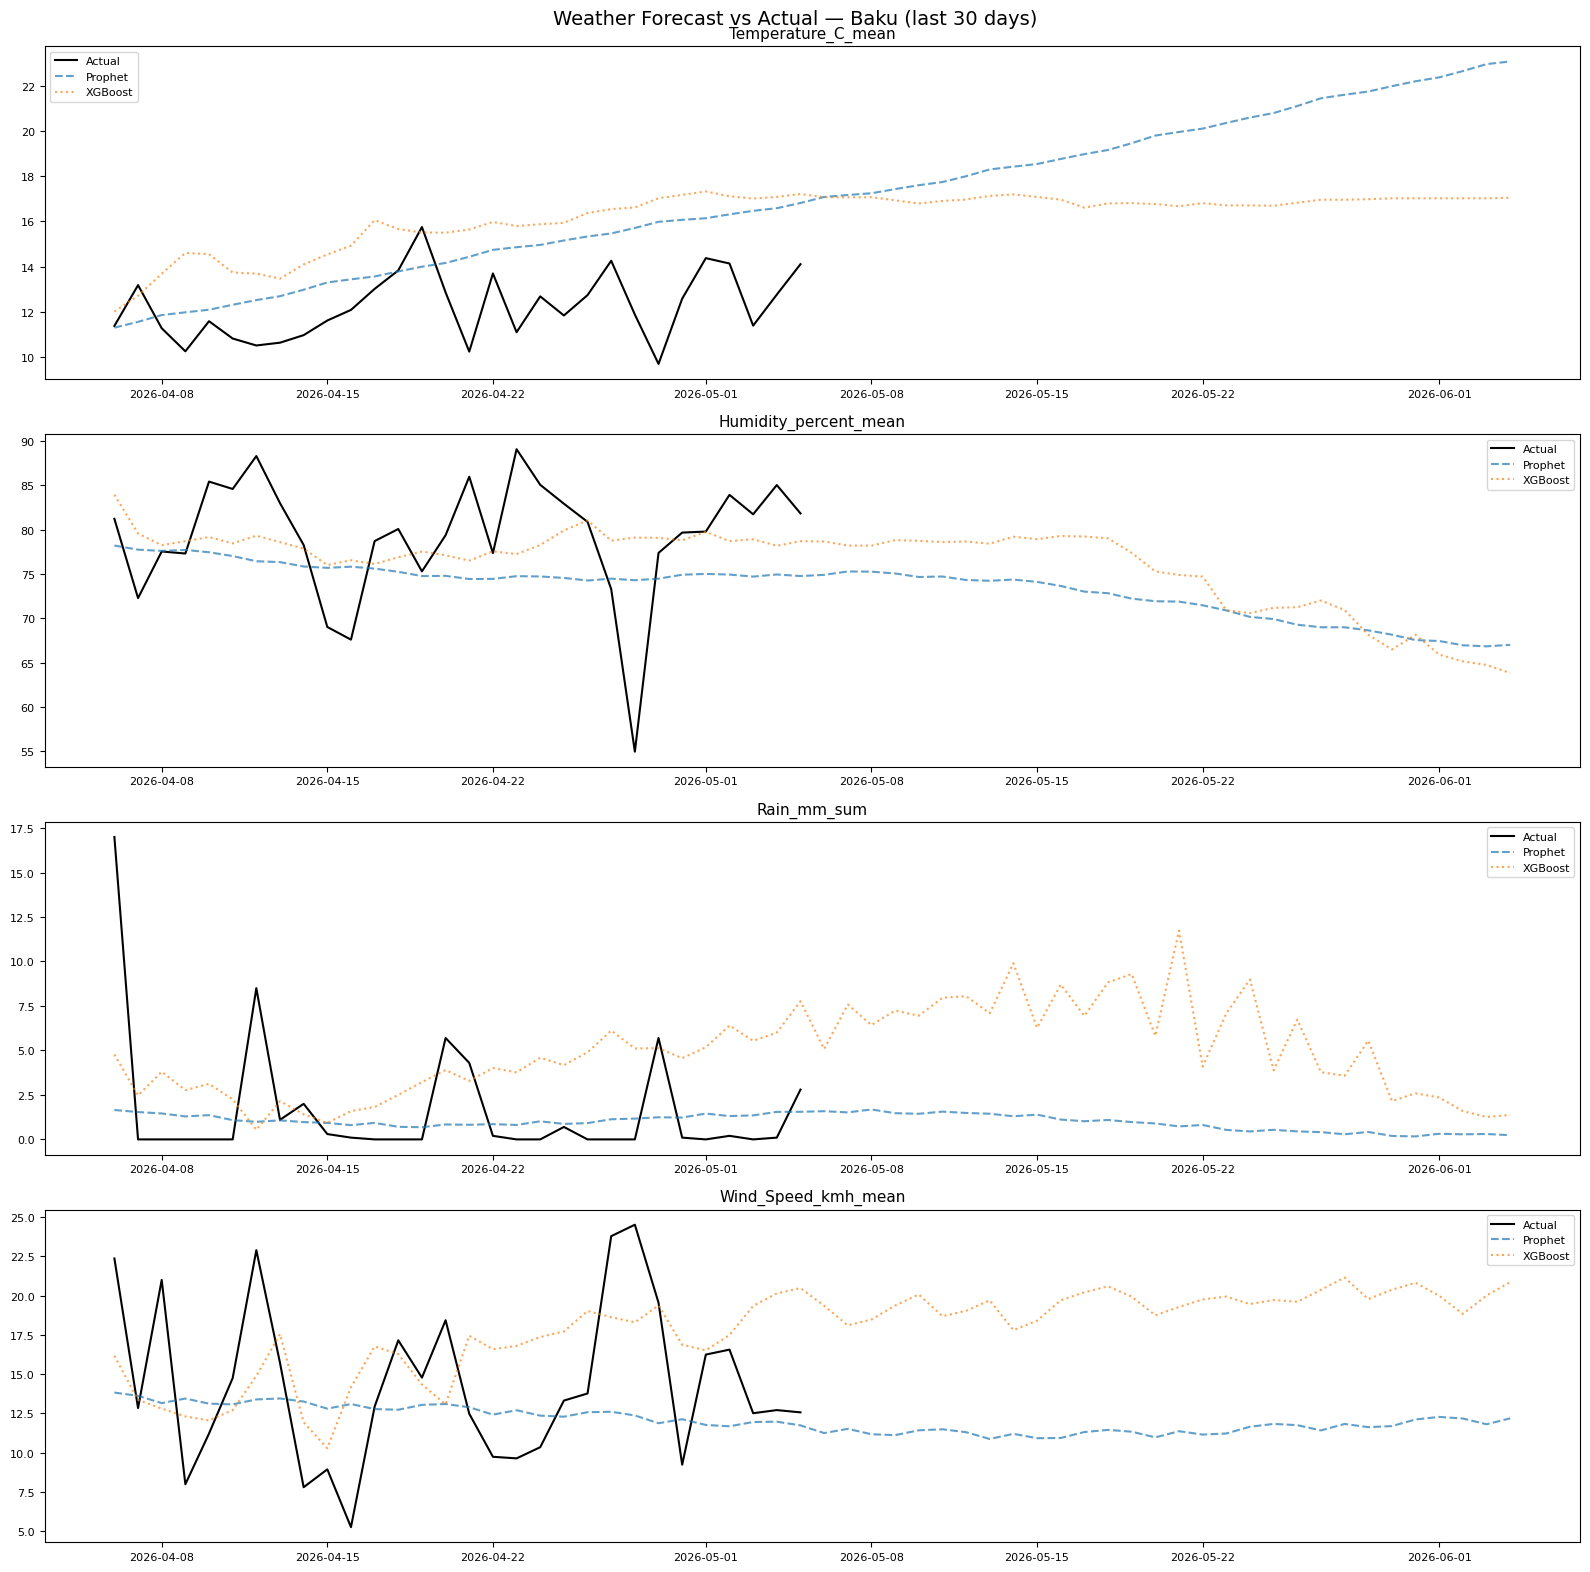


→ Next: open 04_Fire_Detection.ipynb


In [8]:
# ─── §6: Visualization — forecast vs actual ───────────────────────────────
sample_city = "Baku"
n_plot = min(len(TARGETS), 4)

fig, axes = plt.subplots(n_plot, 1, figsize=(16, 4*n_plot))
if n_plot == 1: axes = [axes]
fig.suptitle(f"Weather Forecast vs Actual — {sample_city} (last {HOLDOUT_DAYS} days)",
             fontsize=14)

city_actual = df[(df["City"]==sample_city) & (df["Date"] > cutoff)]

for ax, var in zip(axes, TARGETS[:n_plot]):
    key = (sample_city, var)
    ax.plot(city_actual["Date"], city_actual[var], "k-", label="Actual", linewidth=1.5)

    if key in prophet_results:
        pf = prophet_results[key].copy()
        pf["Date"] = pd.to_datetime(pf["Date"])
        pf = pf[pf["Date"] > cutoff]
        ax.plot(pf["Date"], pf[f"{var}_prophet"], "--", label="Prophet", alpha=0.7)

    if key in xgb_results:
        xf = xgb_results[key].copy()
        xf["Date"] = pd.to_datetime(xf["Date"])
        xf = xf[xf["Date"] > cutoff]
        ax.plot(xf["Date"], xf[f"{var}_xgb"], ":", label="XGBoost", alpha=0.7)

    ax.set_title(var, fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS / "weather_forecast_comparison.png", dpi=150)
plt.show()
print("\n→ Next: open 04_Fire_Detection.ipynb")

In [9]:
# ─── §8: Multi-model weather comparison (LightGBM, CatBoost, Ridge) ──────
# Compares Prophet+XGBoost stacking against additional models on the holdout
# Uses src/modeling.py factory for consistency

import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str(_Path.cwd().parent if _Path.cwd().name == "notebooks" else _Path.cwd()))

try:
    from src.modeling import get_weather_models
    from src.evaluation import weather_metrics

    print("=" * 60)
    print("§8: MULTI-MODEL WEATHER COMPARISON")
    print("=" * 60)

    # Test on first 4 daily targets for the holdout period
    compare_targets = [t for t in TARGETS[:4] if t in df.columns]
    multi_results = []

    for var in compare_targets:
        print(f"\n--- {var} ---")
        models = get_weather_models()

        for city in ["Baku", "Ganja", "Lankaran", "Nakhchivan"]:
            cdf = df[df["City"] == city].sort_values("Date").copy()
            train_c = cdf[cdf["Date"] <= cutoff].copy()
            test_c  = cdf[cdf["Date"] > cutoff].copy()

            if len(train_c) < 30 or len(test_c) < 5 or var not in train_c.columns:
                continue

            # Feature columns for ML models
            feat = [c for c in train_c.columns if c not in
                    ["City", "Date", "Timestamp", var, "Fire_Occurred",
                     "fire_count", "mean_brightness", "max_frp"]
                    and train_c[c].dtype in ["float64", "float32", "int64", "int32"]]

            X_tr_m = train_c[feat].fillna(0)
            y_tr_m = train_c[var].fillna(0)
            X_te_m = test_c[feat].fillna(0)
            y_te_m = test_c[var].fillna(0)

            for mname, model in models.items():
                try:
                    model.fit(X_tr_m, y_tr_m)
                    y_pred_m = model.predict(X_te_m)
                    m = weather_metrics(y_te_m, y_pred_m, var)
                    m["model"] = mname
                    m["city"] = city
                    multi_results.append(m)
                except Exception:
                    pass

    if multi_results:
        multi_df = pd.DataFrame(multi_results)
        print("\nMulti-model comparison (average across cities):")
        summary = multi_df.groupby("model")[["MAE", "RMSE", "R2"]].mean().round(4)
        summary = summary.sort_values("MAE")
        print(summary.to_string())
        multi_df.to_csv(OUTPUTS / "weather_multi_model_comparison.csv", index=False)
        print(f"\nSaved: {OUTPUTS / 'weather_multi_model_comparison.csv'}")
    else:
        print("No multi-model results generated")

except ImportError as e:
    print(f"Skipping multi-model comparison: {e}")
    print("Run from project root or ensure src/ module is accessible")

print("\n→ Next: open 04_Fire_Detection.ipynb")

§8: MULTI-MODEL WEATHER COMPARISON

--- Temperature_C_mean ---



--- Humidity_percent_mean ---



--- Rain_mm_sum ---



--- Wind_Speed_kmh_mean ---



Multi-model comparison (average across cities):
                 MAE    RMSE      R2
model                               
Ridge         0.0015  0.0018  1.0000
ElasticNet    0.1207  0.1538  0.9965
HistGBR       0.1651  0.2564  0.9973
LightGBM      0.1810  0.2770  0.9966
ExtraTrees    0.1914  0.2670  0.9970
XGBoost       0.2077  0.3392  0.9951
RandomForest  0.2449  0.4184  0.9926
CatBoost      0.2482  0.3719  0.9891

Saved: /home/manheim666/Desktop/WildFire-Prediction/outputs/weather_multi_model_comparison.csv

→ Next: open 04_Fire_Detection.ipynb
